# 🔥❄️ Projet : Prédiction de l’Efficacité Énergétique des Bâtiments
Ce notebook applique deux techniques de régression (ELM & BP) sur un dataset énergétique.
Objectif : prédire les charges de chauffage (Y1) et de refroidissement (Y2).

## 📦 Importation des Bibliothèques


In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import Ridge
import warnings
warnings.filterwarnings('ignore')

## 📂 Chargement des Données


In [7]:
df = pd.read_excel("ENB2012_data.xlsx")
df

,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28
...,...,...,...,...,...,...,...,...,...,...
763,0.64,784.0,343.0,220.50,3.5,5,0.4,5,17.88,21.40
764,0.62,808.5,367.5,220.50,3.5,2,0.4,5,16.54,16.88
765,0.62,808.5,367.5,220.50,3.5,3,0.4,5,16.44,17.11
766,0.62,808.5,367.5,220.50,3.5,4,0.4,5,16.48,16.61


## 🧼 Prétraitement des Données


In [8]:
#Afficher les noms de colonnes d'origine
print("Colonnes originales :", df.columns.tolist())

Colonnes originales : ['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'Y1', 'Y2']


In [10]:
#Renommer les colonnes pour plus de clarté
df.columns = [
    "Relative_Compactness",        # X1
    "Surface_Area",                # X2
    "Wall_Area",                   # X3
    "Roof_Area",                   # X4
    "Overall_Height",              # X5
    "Orientation",                 # X6
    "Glazing_Area",                # X7
    "Glazing_Area_Distribution",  # X8
    "Heating_Load",                # Y1
    "Cooling_Load"                 # Y2
]
# Vérifier les nouveaux noms
print("Nouvelles colonnes :", df.columns.tolist())

Nouvelles colonnes : ['Relative_Compactness', 'Surface_Area', 'Wall_Area', 'Roof_Area', 'Overall_Height', 'Orientation', 'Glazing_Area', 'Glazing_Area_Distribution', 'Heating_Load', 'Cooling_Load']


In [12]:
# Sauvegarder le dataset nettoyé 
df.to_csv("ENB2012_data_clean.csv", index=False)

In [13]:
# Chargement des données nettoyés
df = pd.read_csv('ENB2012_data_clean.csv')
df

,Relative_Compactness,Surface_Area,Wall_Area,Roof_Area,Overall_Height,Orientation,Glazing_Area,Glazing_Area_Distribution,Heating_Load,Cooling_Load
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28
...,...,...,...,...,...,...,...,...,...,...
763,0.64,784.0,343.0,220.50,3.5,5,0.4,5,17.88,21.40
764,0.62,808.5,367.5,220.50,3.5,2,0.4,5,16.54,16.88
765,0.62,808.5,367.5,220.50,3.5,3,0.4,5,16.44,17.11
766,0.62,808.5,367.5,220.50,3.5,4,0.4,5,16.48,16.61


In [14]:
# Statistiques de base
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Relative_Compactness       768 non-null    float64
 1   Surface_Area               768 non-null    float64
 2   Wall_Area                  768 non-null    float64
 3   Roof_Area                  768 non-null    float64
 4   Overall_Height             768 non-null    float64
 5   Orientation                768 non-null    int64  
 6   Glazing_Area               768 non-null    float64
 7   Glazing_Area_Distribution  768 non-null    int64  
 8   Heating_Load               768 non-null    float64
 9   Cooling_Load               768 non-null    float64
dtypes: float64(8), int64(2)
memory usage: 60.1 KB


In [15]:
df.describe()

,Relative_Compactness,Surface_Area,Wall_Area,Roof_Area,Overall_Height,Orientation,Glazing_Area,Glazing_Area_Distribution,Heating_Load,Cooling_Load
count,768.000000,768.000000,768.000000,768.000000,768.00000,768.000000,768.000000,768.00000,768.000000,768.000000
mean,0.764167,671.708333,318.500000,176.604167,5.25000,3.500000,0.234375,2.81250,22.307195,24.587760
std,0.105777,88.086116,43.626481,45.165950,1.75114,1.118763,0.133221,1.55096,10.090204,9.513306
min,0.620000,514.500000,245.000000,110.250000,3.50000,2.000000,0.000000,0.00000,6.010000,10.900000
25%,0.682500,606.375000,294.000000,140.875000,3.50000,2.750000,0.100000,1.75000,12.992500,15.620000
50%,0.750000,673.750000,318.500000,183.750000,5.25000,3.500000,0.250000,3.00000,18.950000,22.080000
75%,0.830000,741.125000,343.000000,220.500000,7.00000,4.250000,0.400000,4.00000,31.667500,33.132500
max,0.980000,808.500000,416.500000,220.500000,7.00000,5.000000,0.400000,5.00000,43.100000,48.030000


In [19]:
df.duplicated() #pour determiner si la ligne est répétée ou non 

0      False
1      False
2      False
3      False
4      False
       ...  
763    False
764    False
765    False
766    False
767    False
Length: 768, dtype: bool

In [20]:
df.isna().sum() #pour afficher les valeurs nulls

Relative_Compactness         0
Surface_Area                 0
Wall_Area                    0
Roof_Area                    0
Overall_Height               0
Orientation                  0
Glazing_Area                 0
Glazing_Area_Distribution    0
Heating_Load                 0
Cooling_Load                 0
dtype: int64

## 📊 Exploration des Données (EDA)


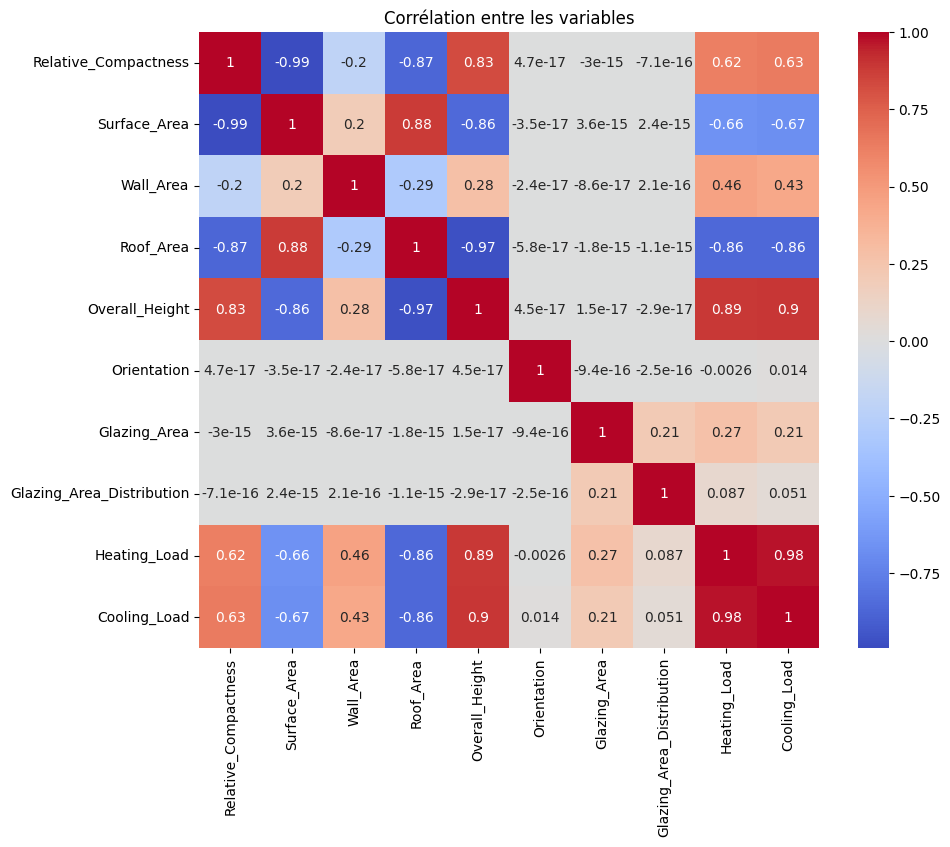

In [21]:
# 🔥 Corrélation: Voir quelles colonnes influencent Y1 et Y2.
#Overall_Height est fortement corrélée avec Heating_Load.
#C’est utile pour :Sélectionner les bonnes features et Comprendre les liens entre variables
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Corrélation entre les variables")
plt.show()

## ✂️ Séparation & ⚖️ Normalisation des Données


In [22]:
#70 % des données servent à entraîner les modèles (les apprendre)
#30 % servent à tester leur performance sur des données jamais vues
X = df.drop(columns=['Heating_Load', 'Cooling_Load'])
y1 = df['Heating_Load']
y2 = df['Cooling_Load']
X_train, X_test, y1_train, y1_test = train_test_split(X, y1, test_size=0.3, random_state=42)
_, _, y2_train, y2_test = train_test_split(X, y2, test_size=0.3, random_state=42)
#But : Mettre toutes les données sur la même échelle (moyenne 0, écart-type 1)
#Pourquoi ? Parce que : Les réseaux de neurones sont sensibles aux grandes différences de valeur Sans ça, l’apprentissage peut être faussé
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 🔥CHALEUR



### 🤖 Modélisation avec Backpropagation (MLPRegressor)

In [29]:
# Modèle BP 
bp_model = MLPRegressor(hidden_layer_sizes=(50,), activation='relu', max_iter=1000, random_state=1)
bp_model.fit(X_train_scaled, y1_train)

y1_pred_bp = bp_model.predict(X_test_scaled)
print('🔹 BP - Heating Load')
print('MAE:', mean_absolute_error(y1_test, y1_pred_bp))
print('RMSE:', mean_squared_error(y1_test, y1_pred_bp, squared=False))
print('R² Score:', r2_score(y1_test, y1_pred_bp))

🔹 BP - Heating Load
MAE: 1.6718256184047264
RMSE: 2.3615202240193143
R² Score: 0.9450007781149967


### ⚡ Modélisation avec Extreme Learning Machine (ELM)


In [25]:
# ⚡ Modèle ELM - Extreme Learning Machine
def ELM(X_train, y_train, X_test, n_hidden=100):  
    input_dim = X_train.shape[1]    
    rng = np.random.RandomState(42)    
    W = rng.normal(size=(input_dim, n_hidden))   
    b = rng.normal(size=(n_hidden,))    
    H = np.tanh(np.dot(X_train, W) + b)    
    model = Ridge(alpha=1.0)    
    model.fit(H, y_train)   
    H_test = np.tanh(np.dot(X_test, W) + b)    
    return model.predict(H_test)
y1_pred_elm = ELM(X_train_scaled, y1_train, X_test_scaled)
print('🔹 ELM - Heating Load')
print('MAE:', mean_absolute_error(y1_test, y1_pred_elm))
print('RMSE:', mean_squared_error(y1_test, y1_pred_elm, squared=False))
print('R² Score:', r2_score(y1_test, y1_pred_elm))

🔹 ELM - Heating Load
MAE: 1.7368545183532629
RMSE: 2.3194969114996575
R² Score: 0.9469407870080413


### Comparaison entre les 2 modèles

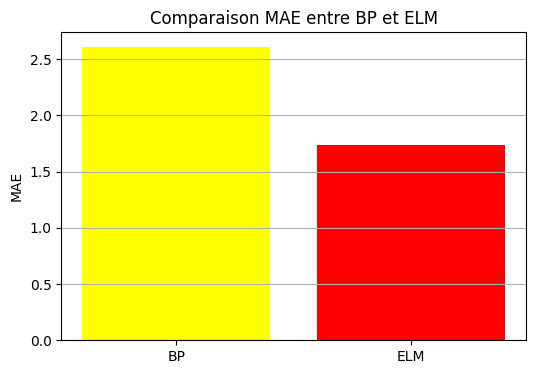

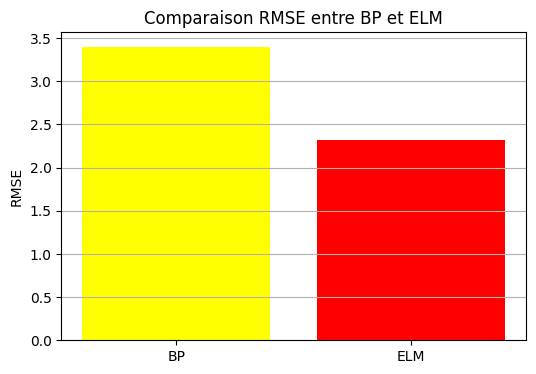

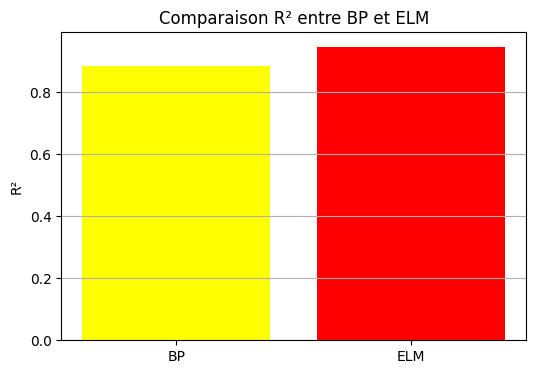

In [41]:
# Scores des deux modèles
scores = {
    "MAE": [
        mean_absolute_error(y1_test, y1_pred_bp),
        mean_absolute_error(y1_test, y1_pred_elm)
    ],
    "RMSE": [
        mean_squared_error(y1_test, y1_pred_bp, squared=False),
        mean_squared_error(y1_test, y1_pred_elm, squared=False)
    ],
    "R²": [
        r2_score(y1_test, y1_pred_bp),
        r2_score(y1_test, y1_pred_elm)
    ]
}

labels = ["BP", "ELM"]
x = range(len(labels))

# Création d'un graphique par métrique
for metric, values in scores.items():
    plt.figure(figsize=(6,4))
    plt.bar(x, values, color=["YELLOW", "RED"])
    plt.xticks(x, labels)
    plt.title(f"Comparaison {metric} entre BP et ELM")
    plt.ylabel(metric)
    plt.grid(axis="y")
    plt.show()



## ❄️REFROIDISSEMENT

### 🤖 Modélisation avec BP

In [32]:
# 🤖 Modèle BP - MLP Regressor
bp_model = MLPRegressor(hidden_layer_sizes=(50,), activation='relu', max_iter=1000, random_state=1)
bp_model.fit(X_train_scaled, y2_train)

y2_pred_bp = bp_model.predict(X_test_scaled)
print('🔹 BP - Cooling Load')
print('MAE:', mean_absolute_error(y2_test, y2_pred_bp))
print('RMSE:', mean_squared_error(y2_test, y2_pred_bp, squared=False))
print('R² Score:', r2_score(y2_test, y2_pred_bp))

🔹 BP - Cooling Load
MAE: 1.9248186850195061
RMSE: 2.7640184205923233
R² Score: 0.915243819360187


### ⚡ Modélisation avec ELM

In [33]:
# ⚡ Modèle ELM - Extreme Learning Machine
def ELM(X_train, y_train, X_test, n_hidden=100):  
    input_dim = X_train.shape[1]    
    rng = np.random.RandomState(42)    
    W = rng.normal(size=(input_dim, n_hidden))   
    b = rng.normal(size=(n_hidden,))    
    H = np.tanh(np.dot(X_train, W) + b)    
    model = Ridge(alpha=1.0)    
    model.fit(H, y_train)   
    H_test = np.tanh(np.dot(X_test, W) + b)    
    return model.predict(H_test)
y2_pred_elm = ELM(X_train_scaled, y1_train, X_test_scaled)
print('🔹 ELM - Cooling Load')
print('MAE:', mean_absolute_error(y2_test, y2_pred_elm))
print('RMSE:', mean_squared_error(y2_test, y2_pred_elm, squared=False))
print('R² Score:', r2_score(y2_test, y2_pred_elm))

🔹 ELM - Cooling Load
MAE: 3.058190944171107
RMSE: 3.843766080232178
R² Score: 0.8360907693627061


### Comparaison entre les 2 modèles

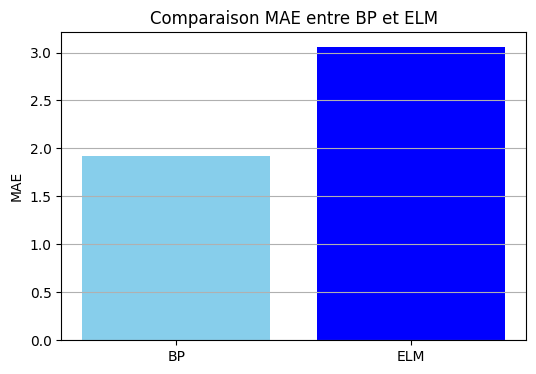

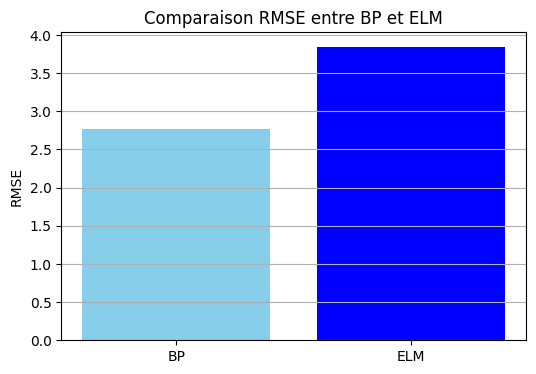

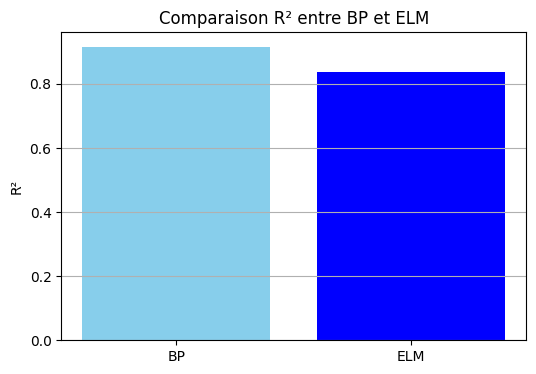

In [43]:
# Scores des deux modèles
scores = {
    "MAE": [
        mean_absolute_error(y2_test, y2_pred_bp),
        mean_absolute_error(y2_test, y2_pred_elm)
    ],
    "RMSE": [
        mean_squared_error(y2_test, y2_pred_bp, squared=False),
        mean_squared_error(y2_test, y2_pred_elm, squared=False)
    ],
    "R²": [
        r2_score(y2_test, y2_pred_bp),
        r2_score(y2_test, y2_pred_elm)
    ]
}

labels = ["BP", "ELM"]
x = range(len(labels))

# Création d'un graphique par métrique
for metric, values in scores.items():
    plt.figure(figsize=(6,4))
    plt.bar(x, values, color=["skyblue", "BLUE"])
    plt.xticks(x, labels)
    plt.title(f"Comparaison {metric} entre BP et ELM")
    plt.ylabel(metric)
    plt.grid(axis="y")
    plt.show()



In [46]:
# --- Import des bibliothèques supplémentaires ---
import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.neural_network import MLPRegressor
import matplotlib.pyplot as plt

# --- 1. Définir la fonction de Grid Search pour ELM ---
def grid_search_elm(X_train, y_train, X_test, y_test, activations, hidden_sizes):
    """
    Boucle sur les fonctions d'activation et tailles cachées,
    entraîne un ELM + Ridge et retourne un DataFrame des performances.
    """
    records = []
    for name, act in activations.items():
        for n_hidden in hidden_sizes:
            # Génération des poids aléatoires
            rng = np.random.RandomState(42)
            W = rng.normal(size=(X_train.shape[1], n_hidden))
            b = rng.normal(size=(n_hidden,))
            # Calcul de la couche cachée
            H_train = act(np.dot(X_train, W) + b)
            H_test  = act(np.dot(X_test,  W) + b)
            # Entraînement du Ridge
            model = Ridge(alpha=1.0)
            model.fit(H_train, y_train)
            # Prédictions
            y_pred = model.predict(H_test)
            # Mesure des métriques
            mae  = mean_absolute_error(y_test, y_pred)
            rmse = mean_squared_error(y_test, y_pred, squared=False)
            r2   = r2_score(y_test, y_pred)
            records.append({
                'act': name,
                'n_hidden': n_hidden,
                'MAE': mae,
                'RMSE': rmse,
                'R2': r2
            })
    return pd.DataFrame(records)

# --- 2. Définir les activations et tailles à tester ---
activations = {
    'tanh': np.tanh,
    'relu': lambda x: np.maximum(0, x),
    'sigmoid': lambda x: 1/(1+np.exp(-x)),
    'linear': lambda x: x
}
hidden_sizes = [50, 100, 200]

# --- 3. Lancer la recherche pour Y1 et Y2 ---
results_y1 = grid_search_elm(X_train_scaled, y1_train, X_test_scaled, y1_test, activations, hidden_sizes)
results_y2 = grid_search_elm(X_train_scaled, y2_train, X_test_scaled, y2_test, activations, hidden_sizes)

# --- 4. Sélection des meilleurs ELM ---
best_y1 = results_y1.loc[results_y1['RMSE'].idxmin()]
best_y2 = results_y2.loc[results_y2['RMSE'].idxmin()]
print("Meilleur ELM Y1 :", best_y1)
print("Meilleur ELM Y2 :", best_y2)




Meilleur ELM Y1 : act             tanh
n_hidden         200
MAE         1.394373
RMSE        1.711154
R2          0.971123
Name: 2, dtype: object
Meilleur ELM Y2 : act             tanh
n_hidden         200
MAE         1.798784
RMSE        2.345479
R2          0.938969
Name: 2, dtype: object


In [53]:
# --- Import des bibliothèques supplémentaires ---
import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.neural_network import MLPRegressor
import matplotlib.pyplot as plt

# --- 1. Définir la fonction de Grid Search pour ELM ---
def grid_search_elm(X_train, y_train, X_test, y_test, activations, hidden_sizes):
    """
    Boucle sur fonctions d'activation et tailles cachées,
    entraîne un ELM + Ridge et retourne un DataFrame des performances.
    """
    records = []
    for name, act in activations.items():
        for n_hidden in hidden_sizes:
            # Génération des poids et biais aléatoires
            rng = np.random.RandomState(42)
            W = rng.normal(size=(X_train.shape[1], n_hidden))
            b = rng.normal(size=(n_hidden,))
            # Calcul de la couche cachée
            H_train = act(np.dot(X_train, W) + b)
            H_test  = act(np.dot(X_test,  W) + b)
            # Entraînement du Ridge
            model = Ridge(alpha=1.0)
            model.fit(H_train, y_train)
            # Prédictions
            y_pred = model.predict(H_test)
            # Mesure des métriques
            mae  = mean_absolute_error(y_test, y_pred)
            rmse = mean_squared_error(y_test, y_pred, squared=False)
            r2   = r2_score(y_test, y_pred)
            # Stockage des résultats
            records.append({
                'act': name,
                'n_hidden': n_hidden,
                'MAE': round(mae, 4),
                'RMSE': round(rmse, 4),
                'R2': round(r2, 4)
            })
    return pd.DataFrame(records)

# --- 2. Paramètres de la recherche ---
activations = {
    'tanh': np.tanh,
    'relu': lambda x: np.maximum(0, x),
    'sigmoid': lambda x: 1/(1+np.exp(-x)),
    'linear': lambda x: x
}
hidden_sizes = [50, 100, 200]

# --- 3. Lancer la recherche pour Y1 et Y2 ---
results_y1 = grid_search_elm(X_train_scaled, y1_train, X_test_scaled, y1_test, activations, hidden_sizes)
results_y2 = grid_search_elm(X_train_scaled, y2_train, X_test_scaled, y2_test, activations, hidden_sizes)

# --- Afficher tous les résultats ---
print("=== Performances ELM pour Y1 ===")
print(results_y1.to_string(index=False))
print("\n=== Performances ELM pour Y2 ===")
print(results_y2.to_string(index=False))

# --- 4. Sélection des meilleurs ELM ---
best_y1 = results_y1.loc[results_y1['RMSE'].idxmin()]
best_y2 = results_y2.loc[results_y2['RMSE'].idxmin()]

print("\n=== Meilleurs ELM ===")
print(f"Y1 -> Activation: {best_y1['act']}, Neurones: {best_y1['n_hidden']}, RMSE: {best_y1['RMSE']}, MAE: {best_y1['MAE']}, R2: {best_y1['R2']}")
print(f"Y2 -> Activation: {best_y2['act']}, Neurones: {best_y2['n_hidden']}, RMSE: {best_y2['RMSE']}, MAE: {best_y2['MAE']}, R2: {best_y2['R2']}")

# --- 5. Grid Search pour MLPRegressor (BP) ---

=== Performances ELM pour Y1 ===
    act  n_hidden    MAE   RMSE     R2
   tanh        50 2.0449 2.7895 0.9233
   tanh       100 1.7369 2.3195 0.9469
   tanh       200 1.3944 1.7112 0.9711
   relu        50 1.9482 2.6139 0.9326
   relu       100 1.6989 2.1899 0.9527
   relu       200 1.7992 2.3539 0.9454
sigmoid        50 1.9672 2.7531 0.9252
sigmoid       100 1.7462 2.4277 0.9419
sigmoid       200 1.5129 2.0336 0.9592
 linear        50 2.1550 2.9732 0.9128
 linear       100 2.1551 2.9732 0.9128
 linear       200 2.1551 2.9731 0.9128

=== Performances ELM pour Y2 ===
    act  n_hidden    MAE   RMSE     R2
   tanh        50 2.3113 3.1584 0.8893
   tanh       100 1.9698 2.6327 0.9231
   tanh       200 1.7988 2.3455 0.9390
   relu        50 2.2495 3.0266 0.8984
   relu       100 2.0367 2.6178 0.9240
   relu       200 2.0367 2.7092 0.9186
sigmoid        50 2.1830 3.0043 0.8999
sigmoid       100 1.9570 2.7805 0.9142
sigmoid       200 1.8026 2.4893 0.9313
 linear        50 2.2578 3.2054 0.88

In [47]:
# --- 5. Grid Search simplifié pour MLPRegressor (BP) ---
bp_records = []
hidden_configs = [(50,), (100,), (50,50)]
activ_bp = ['relu', 'tanh', 'logistic']
for config in hidden_configs:
    for act in activ_bp:
        model = MLPRegressor(hidden_layer_sizes=config, activation=act, max_iter=1000, random_state=1)
        # Y1
        model.fit(X_train_scaled, y1_train)
        y1_pred = model.predict(X_test_scaled)
        r1 = {
            'target':'Y1', 'arch':config, 'act':act,
            'MAE': mean_absolute_error(y1_test, y1_pred),
            'RMSE': mean_squared_error(y1_test, y1_pred, squared=False),
            'R2': r2_score(y1_test, y1_pred)
        }
        # Y2
        model.fit(X_train_scaled, y2_train)
        y2_pred = model.predict(X_test_scaled)
        r2 = {
            'target':'Y2', 'arch':config, 'act':act,
            'MAE': mean_absolute_error(y2_test, y2_pred),
            'RMSE': mean_squared_error(y2_test, y2_pred, squared=False),
            'R2': r2_score(y2_test, y2_pred)
        }
        bp_records.extend([r1, r2])
bp_df = pd.DataFrame(bp_records)

# --- 6. Afficher les meilleurs BP ---
best_bp = bp_df.loc[bp_df.groupby('target')['RMSE'].idxmin()]
print("Meilleurs BP :")
print(best_bp)



Meilleurs BP :
   target      arch   act       MAE      RMSE        R2
12     Y1  (50, 50)  relu  0.515278  0.728782  0.994762
13     Y2  (50, 50)  relu  1.053981  1.483008  0.975601


In [54]:
# --- 5. Grid Search pour MLPRegressor (BP) ---
bp_records = []
hidden_configs = [(50,), (100,), (50,50)]
activ_bp = ['relu', 'tanh', 'logistic']
for config in hidden_configs:
    for act in activ_bp:
        model = MLPRegressor(hidden_layer_sizes=config, activation=act, max_iter=1000, random_state=1)
        # Y1
        model.fit(X_train_scaled, y1_train)
        y1_pred = model.predict(X_test_scaled)
        bp_records.append({'target':'Y1','arch':config,'act':act,
                           'MAE': round(mean_absolute_error(y1_test,y1_pred),4),
                           'RMSE': round(mean_squared_error(y1_test,y1_pred,squared=False),4),
                           'R2': round(r2_score(y1_test,y1_pred),4)})
        # Y2
        model.fit(X_train_scaled, y2_train)
        y2_pred = model.predict(X_test_scaled)
        bp_records.append({'target':'Y2','arch':config,'act':act,
                           'MAE': round(mean_absolute_error(y2_test,y2_pred),4),
                           'RMSE': round(mean_squared_error(y2_test,y2_pred,squared=False),4),
                           'R2': round(r2_score(y2_test,y2_pred),4)})
bp_df = pd.DataFrame(bp_records)

# --- Afficher tous les résultats BP ---
print("\n=== Performances BP (MLPRegressor) ===")
print(bp_df.to_string(index=False))

# --- Afficher les meilleurs BP ---
best_bp = bp_df.loc[bp_df.groupby('target')['RMSE'].idxmin()]
print("\n=== Meilleurs BP ===")
for _, row in best_bp.iterrows():
    print(f"{row['target']} -> Arch: {row['arch']}, Activation: {row['act']}, RMSE: {row['RMSE']}, MAE: {row['MAE']}, R2: {row['R2']}")

# (Le reste du script suit avec comparaisons graphiques, etc.)



=== Performances BP (MLPRegressor) ===
target     arch      act    MAE   RMSE     R2
    Y1    (50,)     relu 1.6718 2.3615 0.9450
    Y2    (50,)     relu 1.9248 2.7640 0.9152
    Y1    (50,)     tanh 1.3942 1.9970 0.9607
    Y2    (50,)     tanh 1.8793 2.7172 0.9181
    Y1    (50,) logistic 2.1203 2.9106 0.9165
    Y2    (50,) logistic 2.2810 3.1553 0.8895
    Y1   (100,)     relu 1.5553 2.2066 0.9520
    Y2   (100,)     relu 1.7920 2.5397 0.9284
    Y1   (100,)     tanh 1.4096 1.9445 0.9627
    Y2   (100,)     tanh 1.7035 2.4824 0.9316
    Y1   (100,) logistic 2.1444 2.9156 0.9162
    Y2   (100,) logistic 2.2282 3.0884 0.8942
    Y1 (50, 50)     relu 0.5153 0.7288 0.9948
    Y2 (50, 50)     relu 1.0540 1.4830 0.9756
    Y1 (50, 50)     tanh 0.7322 1.0517 0.9891
    Y2 (50, 50)     tanh 2.8382 4.0202 0.8207
    Y1 (50, 50) logistic 2.1186 2.9009 0.9170
    Y2 (50, 50) logistic 2.7643 3.9109 0.8303

=== Meilleurs BP ===
Y1 -> Arch: (50, 50), Activation: relu, RMSE: 0.7288, MAE: 0.515

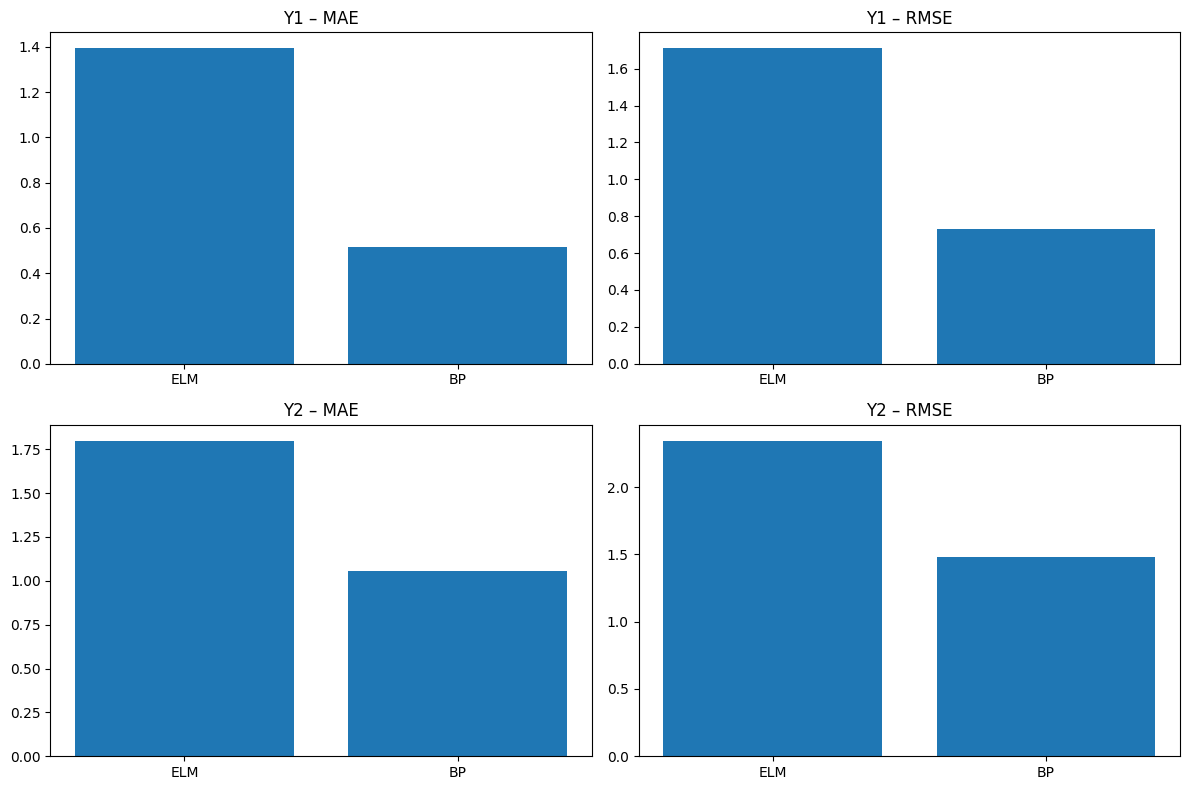

In [48]:
# --- 7. Visualisation comparative MAE/RMSE pour ELM vs BP ---
fig, axes = plt.subplots(2, 2, figsize=(12,8))
# Y1 MAE
axes[0,0].bar(['ELM', 'BP'], [best_y1['MAE'], best_bp.loc[best_bp.target=='Y1','MAE'].values[0]])
axes[0,0].set_title('Y1 – MAE')
# Y1 RMSE
axes[0,1].bar(['ELM', 'BP'], [best_y1['RMSE'], best_bp.loc[best_bp.target=='Y1','RMSE'].values[0]])
axes[0,1].set_title('Y1 – RMSE')
# Y2 MAE
axes[1,0].bar(['ELM', 'BP'], [best_y2['MAE'], best_bp.loc[best_bp.target=='Y2','MAE'].values[0]])
axes[1,0].set_title('Y2 – MAE')
# Y2 RMSE
axes[1,1].bar(['ELM', 'BP'], [best_y2['RMSE'], best_bp.loc[best_bp.target=='Y2','RMSE'].values[0]])
axes[1,1].set_title('Y2 – RMSE')
plt.tight_layout()
plt.show()



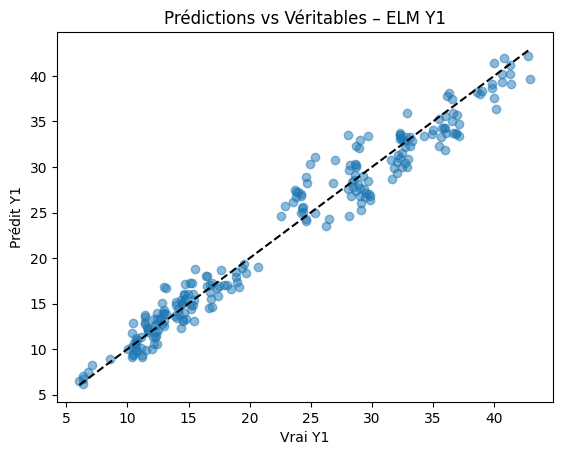

In [49]:
# --- 8. Prédictions vs. valeurs réelles pour le meilleur modèle ELM sur Y1 ---
# Recalcul du meilleur modèle ELM Y1
act = activations[best_y1['act']]
W = np.random.RandomState(42).normal(size=(X_train_scaled.shape[1], best_y1['n_hidden']))
b = np.random.RandomState(42).normal(size=(best_y1['n_hidden'],))
H_test = act(np.dot(X_test_scaled, W) + b)
best_elm_model = Ridge(alpha=1.0).fit(act(np.dot(X_train_scaled, W) + b), y1_train)
y1_pred_best = best_elm_model.predict(H_test)
plt.scatter(y1_test, y1_pred_best, alpha=0.5)
plt.plot([y1_test.min(), y1_test.max()], [y1_test.min(), y1_test.max()], 'k--')
plt.xlabel('Vrai Y1'); plt.ylabel('Prédit Y1'); plt.title('Prédictions vs Véritables – ELM Y1'); plt.show()



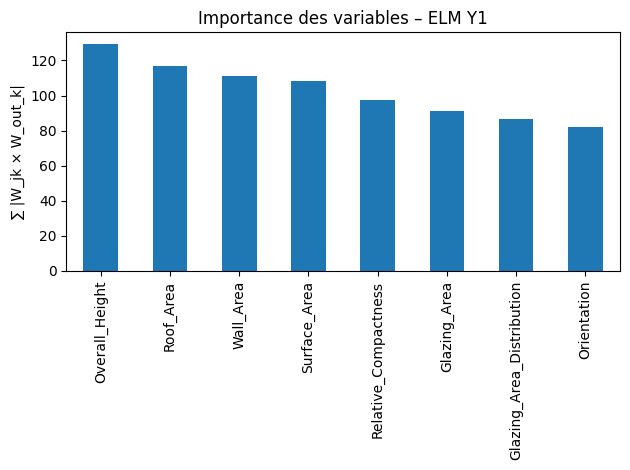

In [51]:
# --- 9. Importance des caractéristiques ELM pour Y1 ---
# Calcul de l'importance par variable d'entrée
# W (n_features x n_hidden) et W_out (n_hidden,)
# importance_j = somme_k |W[j,k] * W_out[k]|
W_out = best_elm_model.coef_  # shape (n_hidden,)
importance = np.sum(np.abs(W * W_out), axis=1)
features = X.columns
imp_df = pd.Series(importance, index=features).sort_values(ascending=False)
imp_df.plot(kind='bar', title='Importance des variables – ELM Y1')
plt.ylabel('∑ |W_jk × W_out_k|') #'Importance (norme des coefficients)'
plt.tight_layout()
plt.show()
